In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

INPUT_DIR = Path('input')

# ─── Palette ────────────────────────────────────────────────────────────────
C_BLUE   = '#2E86AB'
C_GREEN  = '#1D9E75'
C_RED    = '#E24B4A'
C_AMBER  = '#EF9F27'
C_GREY   = '#888780'
C_PURPLE = '#7B5EA7'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

# ════════════════════════════════════════════════════════════════════════════
# LOAD DATA
# ════════════════════════════════════════════════════════════════════════════
print("📂 Loading data …")

orders      = pd.read_csv(INPUT_DIR / 'orders.csv',      parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products    = pd.read_csv(INPUT_DIR / 'products.csv')
shipments   = pd.read_csv(INPUT_DIR / 'shipments.csv',   parse_dates=['ship_date', 'delivery_date'])
payments    = pd.read_csv(INPUT_DIR / 'payments.csv')

print(f"  orders      : {orders.shape}")
print(f"  order_items : {order_items.shape}")
print(f"  products    : {products.shape}")
print(f"  shipments   : {shipments.shape}")
print(f"  payments    : {payments.shape}")


📂 Loading data …
  orders      : (646945, 8)
  order_items : (714669, 7)
  products    : (2412, 8)
  shipments   : (566067, 4)
  payments    : (646945, 4)


In [4]:
# ==========================================
# CELL 1: PREPROCESSING & COHORT LOGIC
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# 1. Chỉ lấy đơn hàng thành công
orders_v = orders[orders['order_status'] == 'delivered'].copy()
orders_v['order_month'] = orders_v['order_date'].dt.to_period('M')

# 2. Tìm đơn hàng đầu tiên của mỗi khách
first_orders = orders_v.sort_values('order_date').groupby('customer_id').first().reset_index()
first_orders = first_orders.rename(columns={
    'order_id': 'first_order_id', 
    'order_date': 'first_order_date',
    'order_month': 'first_month'
})

# 3. Tính khoảng cách tháng (Month Index) cho toàn bộ đơn hàng
# Ví dụ: Mua lại sau 1 tháng -> month_index = 1
orders_v = orders_v.merge(first_orders[['customer_id', 'first_month', 'first_order_id']], on='customer_id')
orders_v['month_index'] = (orders_v['order_month'] - orders_v['first_month']).apply(lambda x: x.n)

# Hàm vẽ Retention Curve dùng chung cho các Cell sau
def plot_retention_curve(df, group_col, title):
    # Tính số lượng KH ở Month 0
    cohort_sizes = df[df['month_index'] == 0].groupby(group_col)['customer_id'].nunique()
    
    # Tính số lượng KH quay lại ở các tháng 1, 2, 3...
    retention = df[df['month_index'] > 0].groupby([group_col, 'month_index'])['customer_id'].nunique().reset_index()
    
    # Ghép cohort size vào để tính %
    retention = retention.merge(cohort_sizes.rename('cohort_size'), on=group_col)
    retention['retention_rate'] = (retention['customer_id'] / retention['cohort_size']) * 100
    
    # Chỉ xem 12 tháng đầu để đỡ nhiễu
    retention = retention[retention['month_index'] <= 12]
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=retention, x='month_index', y='retention_rate', hue=group_col, marker='o', linewidth=2)
    plt.title(title, fontweight='bold')
    plt.xlabel('Tháng sau lần mua đầu tiên (Month Index)')
    plt.ylabel('Tỷ lệ giữ chân - Retention Rate (%)')
    plt.xticks(range(1, 13))
    # Trick: Không set ylim bắt đầu từ 0 để zoom vào sự khác biệt
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print("✅ Đã xử lý xong logic Cohort gốc!")

✅ Đã xử lý xong logic Cohort gốc!


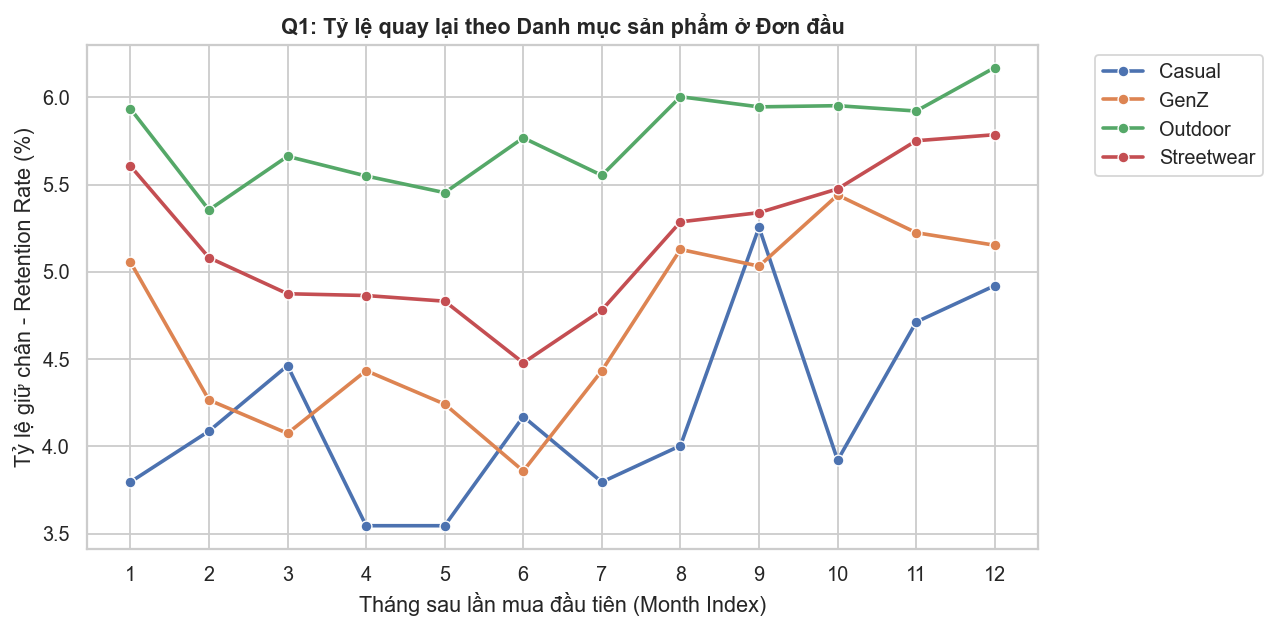

In [5]:
# ==========================================
# CELL 2: Q1 - RETENTION THEO DANH MỤC ĐƠN ĐẦU
# ==========================================
# Gắn category cho đơn đầu tiên
first_items = order_items[order_items['order_id'].isin(first_orders['first_order_id'])]
first_items = first_items.merge(products[['product_id', 'category']], on='product_id', how='left')

# Tính doanh thu từng item để chọn Main Category cho đơn đầu
first_items['net_rev'] = (first_items['unit_price'] * first_items['quantity']) - first_items['discount_amount']
main_cat = first_items.sort_values('net_rev', ascending=False).groupby('order_id').first().reset_index()

# Gắn nhãn category vào orders_v
cat_mapping = main_cat.set_index('order_id')['category'].to_dict()
orders_v['first_category'] = orders_v['first_order_id'].map(cat_mapping)

plot_retention_curve(orders_v, 'first_category', 'Q1: Tỷ lệ quay lại theo Danh mục sản phẩm ở Đơn đầu')


── [3] Tác động vận hành (Quantile Binning & Auto-Zoom) ──
  Delivery quantiles: 33%=3d, 66%=5d


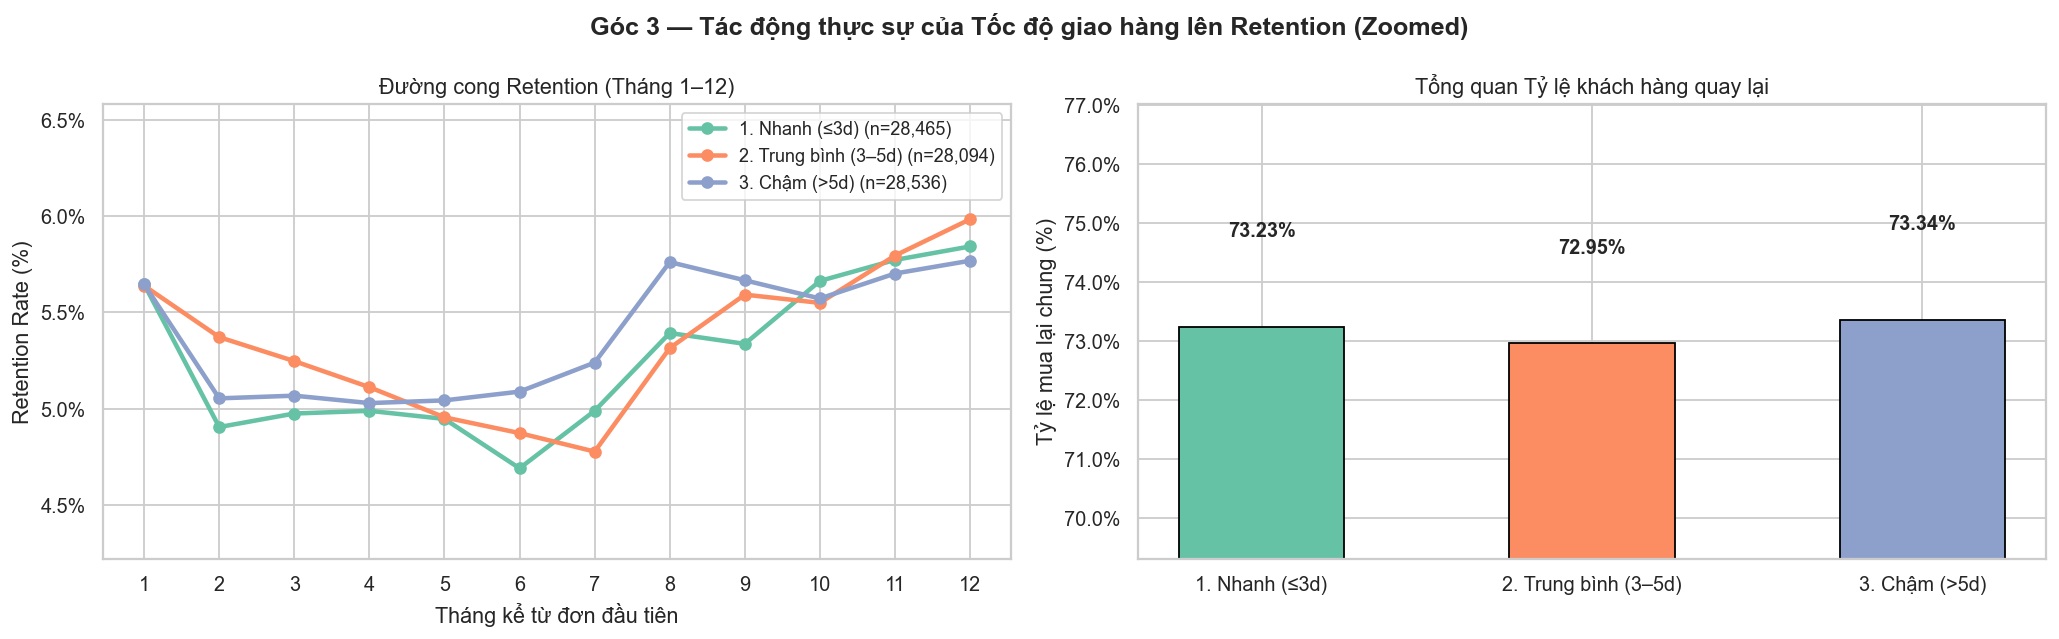

In [12]:
# ════════════════════════════════════════════════════════════════════════════
# 3. TÁC ĐỘNG VẬN HÀNH — Giao chậm có làm khách bỏ đi không? (ZOOMED VERSION)
# ════════════════════════════════════════════════════════════════════════════
print("\n── [3] Tác động vận hành (Quantile Binning & Auto-Zoom) ──")

# 1. Tính days_to_deliver thực tế
ship_valid = shipments.dropna(subset=['ship_date', 'delivery_date']).copy()
# Ép kiểu datetime để đảm bảo an toàn
ship_valid['ship_date'] = pd.to_datetime(ship_valid['ship_date'])
ship_valid['delivery_date'] = pd.to_datetime(ship_valid['delivery_date'])
ship_valid['days_to_deliver'] = (ship_valid['delivery_date'] - ship_valid['ship_date']).dt.days

# Lấy thông tin giao hàng của đơn đầu tiên
first_order_ship = (
    first_orders
    .merge(ship_valid[['order_id', 'days_to_deliver']], left_on='first_order_id', right_on='order_id', how='left')
    .groupby('customer_id')['days_to_deliver']
    .first()
    .reset_index()
)

# 2. Binning bằng Quantiles (Logic của bạn giữ nguyên, cực chuẩn)
q33 = first_order_ship['days_to_deliver'].quantile(0.33)
q66 = first_order_ship['days_to_deliver'].quantile(0.66)
print(f"  Delivery quantiles: 33%={q33:.0f}d, 66%={q66:.0f}d")

def bin_delivery(d):
    if pd.isna(d): return 'Không có ship data'
    elif d <= q33: return f'1. Nhanh (≤{q33:.0f}d)'
    elif d <= q66: return f'2. Trung bình ({q33:.0f}–{q66:.0f}d)'
    else:          return f'3. Chậm (>{q66:.0f}d)'

first_order_ship['delivery_group'] = first_order_ship['days_to_deliver'].apply(bin_delivery)

# Gắn vào orders_v (Bảng đã chứa month_index từ Cell 1)
orders_with_ship = orders_v.merge(
    first_order_ship[['customer_id', 'delivery_group']],
    on='customer_id', how='inner'
)
orders_ship_clean = orders_with_ship[orders_with_ship['delivery_group'] != 'Không có ship data']

# 3. Tính Retention thủ công (Thay cho hàm calc_retention)
cohort_sizes = orders_ship_clean[orders_ship_clean['month_index'] == 0].groupby('delivery_group')['customer_id'].nunique()
ret_ship = orders_ship_clean[orders_ship_clean['month_index'] > 0].groupby(['delivery_group', 'month_index'])['customer_id'].nunique().reset_index()
ret_ship = ret_ship.merge(cohort_sizes.rename('n_cohort'), on='delivery_group')
ret_ship['retention_rate'] = (ret_ship['customer_id'] / ret_ship['n_cohort']) * 100
ret_ship = ret_ship[ret_ship['month_index'] <= 12] # Chỉ coi 12 tháng đầu

# 4. VẼ BIỂU ĐỒ VỚI AUTO-ZOOM
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Góc 3 — Tác động thực sự của Tốc độ giao hàng lên Retention (Zoomed)', fontsize=14, fontweight='bold')

# Bảng màu
colors_ship = {'1. Nhanh (≤3d)': '#1D9E75', '2. Trung bình (3–5d)': '#EF9F27', '3. Chậm (>5d)': '#E24B4A'}
# Fallback colors nếu quantile ra bin khác
palette = sns.color_palette("Set2", 3)
colors_ship = {grp: palette[i] for i, grp in enumerate(sorted(ret_ship['delivery_group'].unique()))}

# Trái: Line Chart (Retention)
ax = axes[0]
for grp, sub in ret_ship.groupby('delivery_group'):
    ax.plot(sub['month_index'], sub['retention_rate'],
            marker='o', markersize=6, label=f"{grp} (n={sub['n_cohort'].iloc[0]:,})",
            color=colors_ship.get(grp, '#888780'), linewidth=2.5)

ax.set_xlabel('Tháng kể từ đơn đầu tiên')
ax.set_ylabel('Retention Rate (%)')
ax.set_title('Đường cong Retention (Tháng 1–12)')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=1))
ax.set_xticks(range(1, 13))

# BÍ QUYẾT: Dynamic Zoom cho trục Y (Tự động cắt ngọn/đáy thừa)
y_min = ret_ship['retention_rate'].min() * 0.9  # Rút đáy
y_max = ret_ship['retention_rate'].max() * 1.1  # Nới đỉnh
ax.set_ylim(y_min, y_max) 

# Phải: Bar Chart (Overall Repeat Rate)
ax2 = axes[1]
# Lọc khách hàng có quay lại (total orders > 1)
order_counts = orders_ship_clean.groupby('customer_id')['first_order_id'].count().reset_index(name='total_orders')
repeat_cust_ids = order_counts[order_counts['total_orders'] > 1]['customer_id']

repeat_ship = first_order_ship[first_order_ship['delivery_group'] != 'Không có ship data'].copy()
repeat_ship['is_repeat'] = repeat_ship['customer_id'].isin(repeat_cust_ids)

rr_ship = (
    repeat_ship.groupby('delivery_group')['is_repeat']
    .agg(['sum', 'count'])
    .assign(repeat_rate=lambda d: d['sum'] / d['count'] * 100)
    .reset_index()
    .sort_values('delivery_group')
)

bars = ax2.bar(rr_ship['delivery_group'], rr_ship['repeat_rate'],
               color=[colors_ship.get(g, '#888780') for g in rr_ship['delivery_group']],
               width=0.5, edgecolor='black', linewidth=1)

for bar, (_, row) in zip(bars, rr_ship.iterrows()):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (rr_ship['repeat_rate'].max()*0.02),
             f"{row['repeat_rate']:.2f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel('Tỷ lệ mua lại chung (%)')
ax2.set_title('Tổng quan Tỷ lệ khách hàng quay lại')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=1))

# BÍ QUYẾT: Dynamic Zoom cho Bar Chart (Cắt bỏ phần 0 ở dưới để thấy độ lệch ngọn)
y2_min = rr_ship['repeat_rate'].min() * 0.95
y2_max = rr_ship['repeat_rate'].max() * 1.05
ax2.set_ylim(y2_min, y2_max)

plt.tight_layout()
plt.savefig('retention_3_shipping_zoomed.png', bbox_inches='tight')
plt.show()

In [13]:
# ==========================================
# CELL 4 (TỐI GIẢN): Q3 - TÁC ĐỘNG VẬN HÀNH ĐƠN ĐẦU
# ==========================================
# Lọc thông tin ship của những đơn hàng đầu tiên
first_ship = shipments[shipments['order_id'].isin(first_orders['first_order_id'])].copy()

# Dùng trực tiếp cột days_to_ship mà file bạn đang có
first_ship['delivery_speed'] = pd.cut(
    first_ship['days_to_ship'], 
    bins=[-1, 2, 4, 99], 
    labels=['Nhanh (<=2 ngày)', 'Bình thường (3-4 ngày)', 'Chậm (>4 ngày)']
)

# Gắn nhãn tốc độ vào dữ liệu orders
ship_mapping = first_ship.set_index('order_id')['delivery_speed'].to_dict()
orders_v['delivery_speed'] = orders_v['first_order_id'].map(ship_mapping)

# Vẽ biểu đồ
plot_retention_curve(
    orders_v.dropna(subset=['delivery_speed']), 
    'delivery_speed', 
    'Q3: Tỷ lệ quay lại theo Thời gian xử lý đơn đầu (days_to_ship)'
)

KeyError: 'days_to_ship'

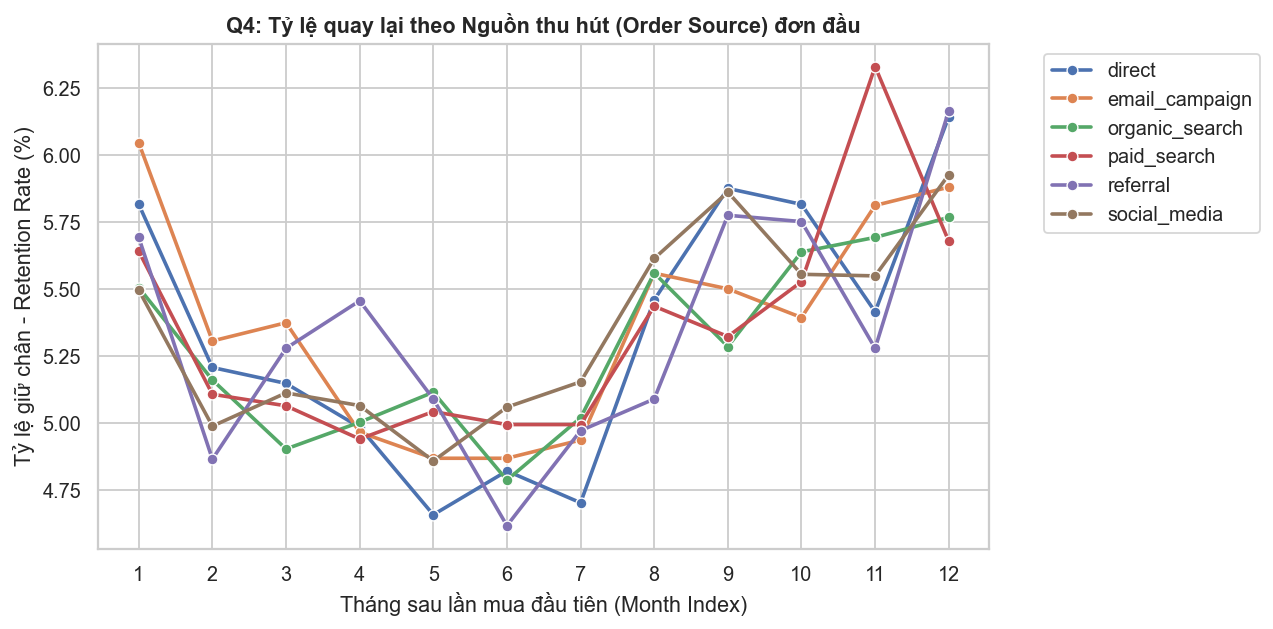

In [8]:
# ==========================================
# CELL 5: Q4 - RETENTION THEO KÊNH THU HÚT
# ==========================================
# orders_v đã chứa order_source gốc, ta cần gán source của đơn ĐẦU TIÊN cho tất cả các đơn của KH đó
source_mapping = first_orders.set_index('customer_id')['order_source'].to_dict()
orders_v['first_source'] = orders_v['customer_id'].map(source_mapping)

plot_retention_curve(orders_v, 'first_source', 'Q4: Tỷ lệ quay lại theo Nguồn thu hút (Order Source) đơn đầu')